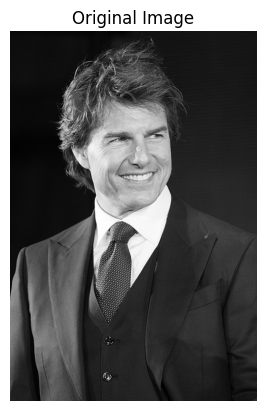

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
img = cv2.imread("TC_JR.jpg", cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

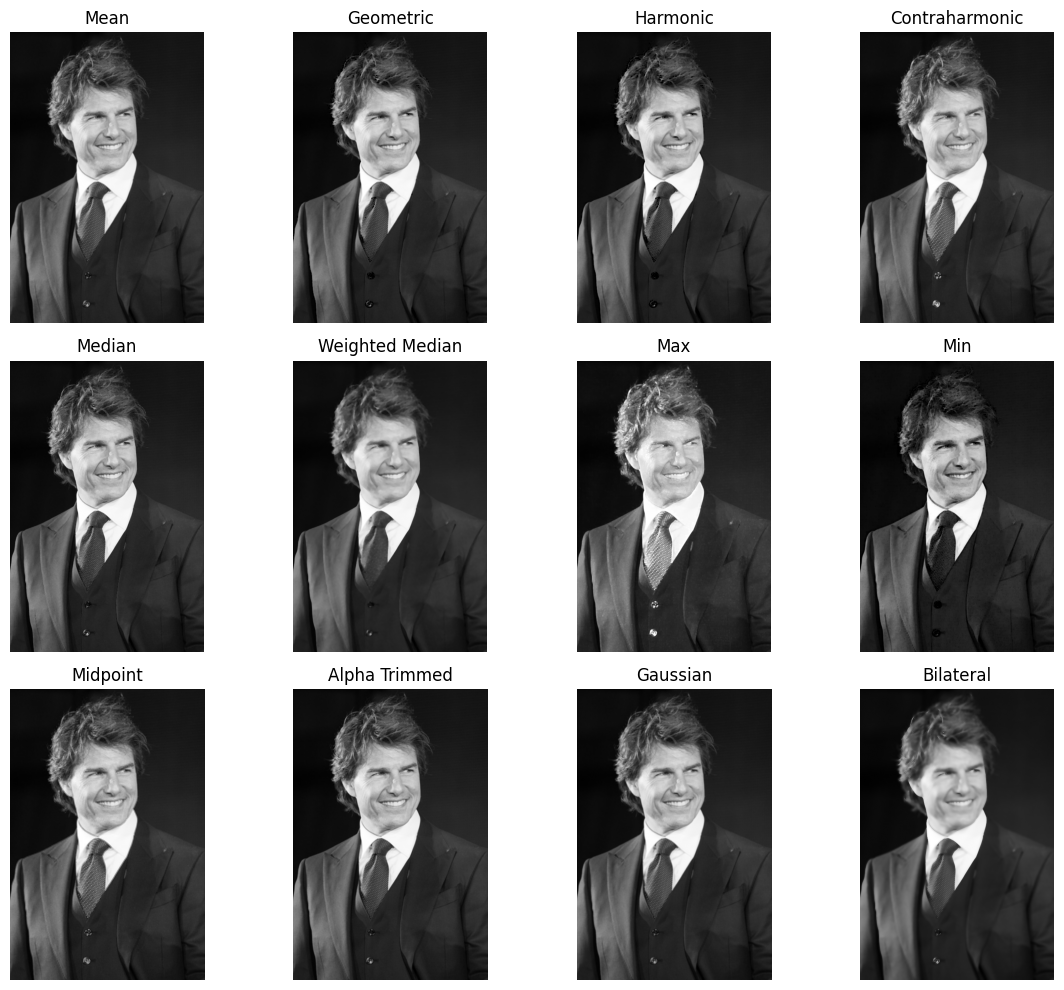

In [ ]:
# 1. Arithmetic Mean Filter
mean = cv2.blur(img, (3, 3))


# 2. Geometric Mean Filter
def geometric_mean_filter(image, ksize=3):
    padded = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_REFLECT)
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i : i + ksize, j : j + ksize].astype(np.float32)
            out[i, j] = np.exp(np.mean(np.log(region + 1e-5)))
    return np.uint8(out)


geo = geometric_mean_filter(img)


# 3. Harmonic Mean Filter
def harmonic_mean_filter(image, ksize=3):
    padded = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_REFLECT)
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i : i + ksize, j : j + ksize].astype(np.float32)
            out[i, j] = ksize * ksize / np.sum(1.0 / (region + 1e-5))
    return np.uint8(out)


harm = harmonic_mean_filter(img)


# 4. Contraharmonic Mean Filter (Q = 1)
def contraharmonic_mean_filter(image, ksize=3, Q=1.0):
    padded = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_REFLECT)
    out = np.zeros_like(image, dtype=np.float32)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i : i + ksize, j : j + ksize].astype(np.float32)
            num = np.sum(np.power(region, Q + 1))
            den = np.sum(np.power(region, Q))
            out[i, j] = num / (den + 1e-5)
    return np.uint8(out)


contra = contraharmonic_mean_filter(img, Q=1)

# 5. Median Filter
median = cv2.medianBlur(img, 3)

# 6. Weighted Median Filter (approximation using larger kernel)
weighted_median = cv2.medianBlur(img, 5)

# 7. Max and Min Filters
kernel = np.ones((3, 3), np.uint8)
maxf = cv2.dilate(img, kernel)
minf = cv2.erode(img, kernel)

# 8. Midpoint Filter
midpoint = ((maxf.astype(np.float32) + minf.astype(np.float32)) / 2).astype(np.uint8)


# 9. Alpha-Trimmed Mean Filter (d=2)
def alpha_trimmed_mean_filter(image, ksize=3, d=2):
    padded = cv2.copyMakeBorder(image, 1, 1, 1, 1, cv2.BORDER_REFLECT)
    out = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i : i + ksize, j : j + ksize].flatten()
            region.sort()
            trimmed = region[d // 2 : -d // 2]
            out[i, j] = np.mean(trimmed)
    return np.uint8(out)


alpha_trim = alpha_trimmed_mean_filter(img)

# 10. Gaussian Filter
gaussian = cv2.GaussianBlur(img, (5, 5), 1)

# 11. Bilateral Filter
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

titles = [
    "Mean",
    "Geometric",
    "Harmonic",
    "Contraharmonic",
    "Median",
    "Weighted Median",
    "Max",
    "Min",
    "Midpoint",
    "Alpha Trimmed",
    "Gaussian",
    "Bilateral",
]
images = [
    mean,
    geo,
    harm,
    contra,
    median,
    weighted_median,
    maxf,
    minf,
    midpoint,
    alpha_trim,
    gaussian,
    bilateral,
]

plt.figure(figsize=(12, 10))
for i in range(len(images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

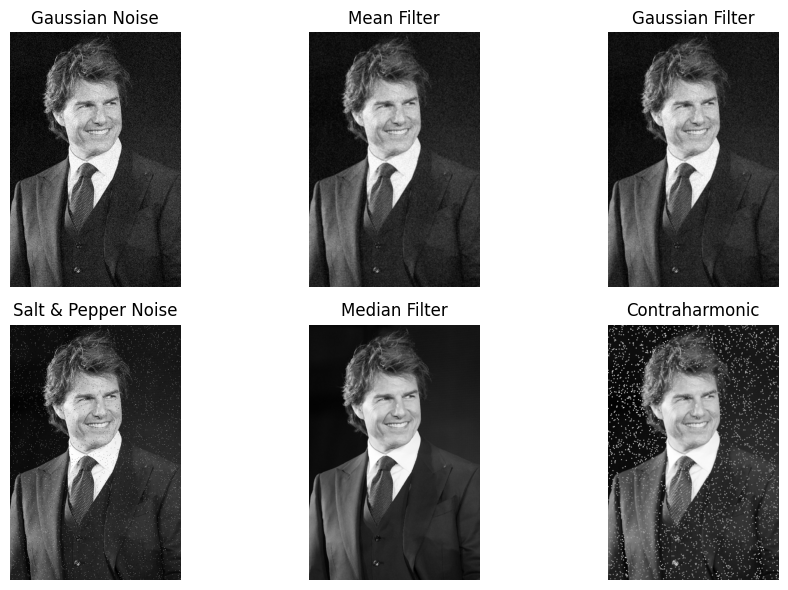

In [ ]:
# Add Gaussian noise
gaussian_noise = img + 20 * np.random.randn(*img.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

# Remove Gaussian noise using Mean and Gaussian filters
den_mean = cv2.blur(gaussian_noise, (3, 3))
den_gauss = cv2.GaussianBlur(gaussian_noise, (3, 3), 1)


# Add salt & pepper noise
def salt_pepper_noise(image, prob=0.02):
    noisy = image.copy()
    num_salt = int(prob * image.size * 0.5)
    num_pepper = int(prob * image.size * 0.5)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy[coords[0], coords[1]] = 255
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy[coords[0], coords[1]] = 0
    return noisy


sp_noise = salt_pepper_noise(img)

# Remove salt & pepper noise using Median and Contraharmonic filters
den_median = cv2.medianBlur(sp_noise, 3)
den_contra = contraharmonic_mean_filter(sp_noise, Q=1)

plt.figure(figsize=(10, 6))
titles = [
    "Gaussian Noise",
    "Mean Filter",
    "Gaussian Filter",
    "Salt & Pepper Noise",
    "Median Filter",
    "Contraharmonic",
]
images = [gaussian_noise, den_mean, den_gauss, sp_noise, den_median, den_contra]
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

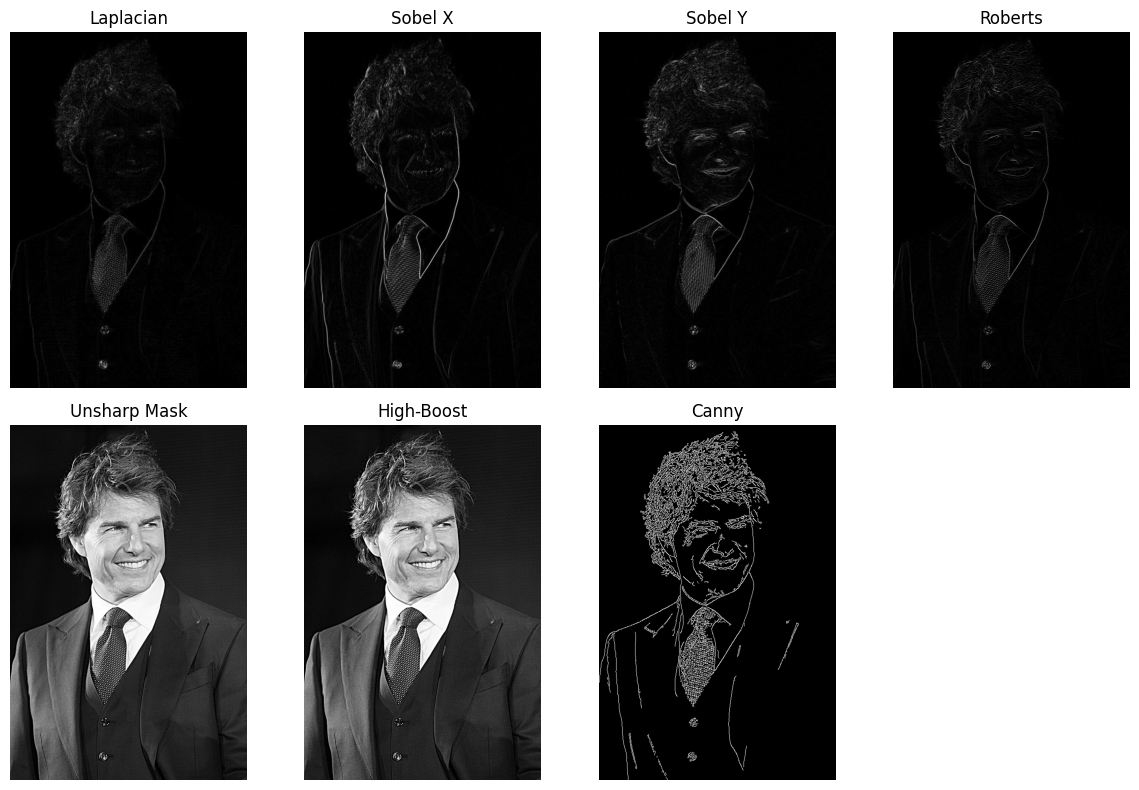

In [ ]:
# Edge Detection
lap = cv2.Laplacian(img, cv2.CV_64F)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
roberts_x = np.array([[1, 0], [0, -1]], dtype=np.float32)
roberts_y = np.array([[0, 1], [-1, 0]], dtype=np.float32)
roberts_x_img = cv2.filter2D(img, -1, roberts_x)
roberts_y_img = cv2.filter2D(img, -1, roberts_y)
roberts = cv2.addWeighted(roberts_x_img, 0.5, roberts_y_img, 0.5, 0)

# Unsharp Masking
gauss_blur = cv2.GaussianBlur(img, (9, 9), 10)
unsharp = cv2.addWeighted(img, 1.5, gauss_blur, -0.5, 0)

# High-Boost Filtering
A = 1.7
high_boost = cv2.addWeighted(img, A, gauss_blur, -(A - 1), 0)

# Canny Edge Detector
canny = cv2.Canny(img, 100, 200)

plt.figure(figsize=(12, 8))
titles = [
    "Laplacian",
    "Sobel X",
    "Sobel Y",
    "Roberts",
    "Unsharp Mask",
    "High-Boost",
    "Canny",
]
images = [lap, sobelx, sobely, roberts, unsharp, high_boost, canny]
for i in range(len(images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.abs(images[i]), cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

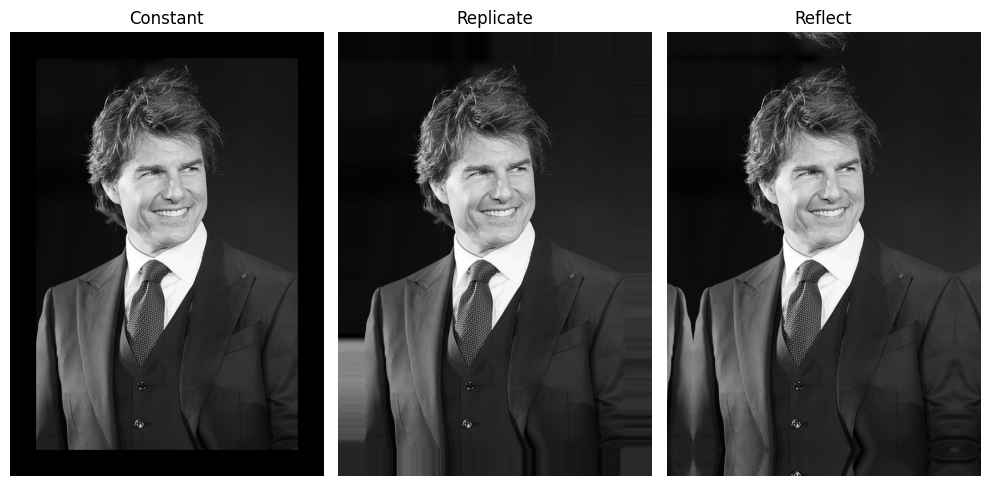

In [ ]:
# Padding types
pad_constant = cv2.copyMakeBorder(img, 50, 50, 50, 50, cv2.BORDER_CONSTANT, value=0)
pad_replicate = cv2.copyMakeBorder(img, 50, 50, 50, 50, cv2.BORDER_REPLICATE)
pad_reflect = cv2.copyMakeBorder(img, 50, 50, 50, 50, cv2.BORDER_REFLECT)

plt.figure(figsize=(10, 6))
titles = ["Constant", "Replicate", "Reflect"]
images = [pad_constant, pad_replicate, pad_reflect]
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()